In [1]:
!pip install -q scikit-learn Sastrawi matplotlib seaborn wordcloud pandas numpy joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.0 MB/s eta 0:00:00


In [2]:
try:
    from google.colab import files
    files.upload()  # pilih file dataset CSV
except Exception as e:
    print("bukan colab:", e)

Saving Dataset penelitian DSAI(3000) NEW.csv to Dataset penelitian DSAI(3000) NEW.csv


In [3]:
import os, re, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             precision_recall_fscore_support)
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['savefig.dpi']=300; plt.rcParams['figure.dpi']=120
RS=42; ORDER=['negative','neutral','positive']
PAL={'negative':'#E74C3C','neutral':'#95A5A6','positive':'#2ECC71'}
os.makedirs('figures', exist_ok=True)
def savefig(n): plt.tight_layout(); plt.savefig(f'figures/{n}.png', bbox_inches='tight'); plt.show()

# Pengaturan
DATASET_PATH = 'Dataset penelitian DSAI(3000) NEW.csv'
USE_STEMMING = False   # False = konfigurasi utama; set True untuk menguji efek stemming
SHOW_RBF_BASELINE = True  # RBF hanya sebagai pembanding, bukan model final

## 1) LOAD DATA

In [4]:
df = pd.read_csv(DATASET_PATH)
df = df[['author','comment','manual_sentiment']].dropna(subset=['comment','manual_sentiment'])
df['manual_sentiment'] = df['manual_sentiment'].str.lower().str.strip()
df = df[df['manual_sentiment'].isin(ORDER)].copy()
print('Jumlah data:', len(df)); print(df['manual_sentiment'].value_counts())

Jumlah data: 3000
manual_sentiment
positive    1000
neutral     1000
negative    1000
Name: count, dtype: int64


## 2) Preprocessing (tanpa stemming; emoji jadi token; penanganan negasi)

In [5]:
slang = {
 'gak':'tidak','ga':'tidak','gk':'tidak','nggak':'tidak','ngga':'tidak','enggak':'tidak','tdk':'tidak','tak':'tidak','engga':'tidak',
 'udah':'sudah','udh':'sudah','blm':'belum','aja':'saja','aj':'saja','bgt':'banget','bngt':'banget','yg':'yang','dgn':'dengan',
 'utk':'untuk','klo':'kalau','kalo':'kalau','gmn':'bagaimana','gimana':'bagaimana','knp':'kenapa','krn':'karena','karna':'karena',
 'jd':'jadi','jdi':'jadi','nih':'ini','tuh':'itu','org':'orang','bgs':'bagus','mantul':'mantap','gokil':'keren','kerenn':'keren',
 'vidio':'video','vid':'video','sub':'subscribe','min':'admin','gw':'saya','gue':'saya','gua':'saya','lu':'kamu','lo':'kamu',
 'elu':'kamu','ane':'saya','ente':'kamu','sgt':'sangat','dr':'dari','sy':'saya','tp':'tapi','tpi':'tapi',
}
POS_EMO = set('😍🥰😘❤️♥️💕👍🔥🎉😊🙏👏🤩😭🥹✨💯🥳😂🤣💖🙌👌🥲😀😁😃😄')
NEG_EMO = set('😡🤬👎😠💩🤮😤😒🙄😞😔💔😢😣😩😫🙁')
NEG_WORDS = {'tidak','bukan','jangan','belum','tanpa','kurang'}
stemmer = StemmerFactory().create_stemmer()
stop_words = set(StopWordRemoverFactory().get_stop_words()) - NEG_WORDS - {'tapi','sangat','paling'}
url_re=re.compile(r'http\S+|www\.\S+'); mention_re=re.compile(r'@\w+|#\w+')
nonword_re=re.compile(r'[^a-z\s]'); elong_re=re.compile(r'(.)\1{2,}')

def preprocess(text):
    t=str(text).lower()
    npos=sum(t.count(e) for e in POS_EMO); nneg=sum(t.count(e) for e in NEG_EMO)
    t=url_re.sub(' ',t); t=mention_re.sub(' ',t); t=elong_re.sub(r'\1',t)
    t=nonword_re.sub(' ',t); t=re.sub(r'\s+',' ',t).strip()
    tokens=[slang.get(w,w) for w in t.split()]
    tokens=[w for w in tokens if w not in stop_words and len(w)>1]
    t=' '.join(tokens)
    if USE_STEMMING: t=stemmer.stem(t)
    toks=t.split(); out=[]; i=0
    while i<len(toks):
        if toks[i] in NEG_WORDS and i+1<len(toks): out.append(toks[i]+'_'+toks[i+1]); i+=2
        else: out.append(toks[i]); i+=1
    out += ['emopos']*min(npos,3) + ['emoneg']*min(nneg,3)
    return ' '.join(out)

print(f'\nPreprocessing (USE_STEMMING={USE_STEMMING})...')
df['clean']=df['comment'].apply(preprocess)
df=df[df['clean'].str.len()>0].copy()
print('Sisa data:', len(df))


Preprocessing (USE_STEMMING=False)...
Sisa data: 2943


## 3) FITUR: Dual TF-IDF (kata 1-2 + karakter 2-5)

In [6]:
X,y=df['clean'],df['manual_sentiment']
Xtr_txt,Xte_txt,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=RS,stratify=y)
word_vec=TfidfVectorizer(analyzer='word',ngram_range=(1,2),max_features=15000,min_df=2,sublinear_tf=True)
char_vec=TfidfVectorizer(analyzer='char_wb',ngram_range=(2,5),max_features=20000,min_df=3,sublinear_tf=True)
feats=FeatureUnion([('word',word_vec),('char',char_vec)])
Xtr=feats.fit_transform(Xtr_txt); Xte=feats.transform(Xte_txt)
print('Dimensi fitur:',Xtr.shape[1])

Dimensi fitur: 18772


## 4) MODEL LINEAR + ENSEMBLE  (TANPA RBF sebagai model final)


=== Perbandingan Model (Akurasi CV) ===
  Ensemble (soft-vote)            : 70.82%
  LogReg                          : 70.65%
  LinearSVC                       : 70.39%
  SVM-RBF (baseline)              : 70.14%
  ComplementNB                    : 69.16%


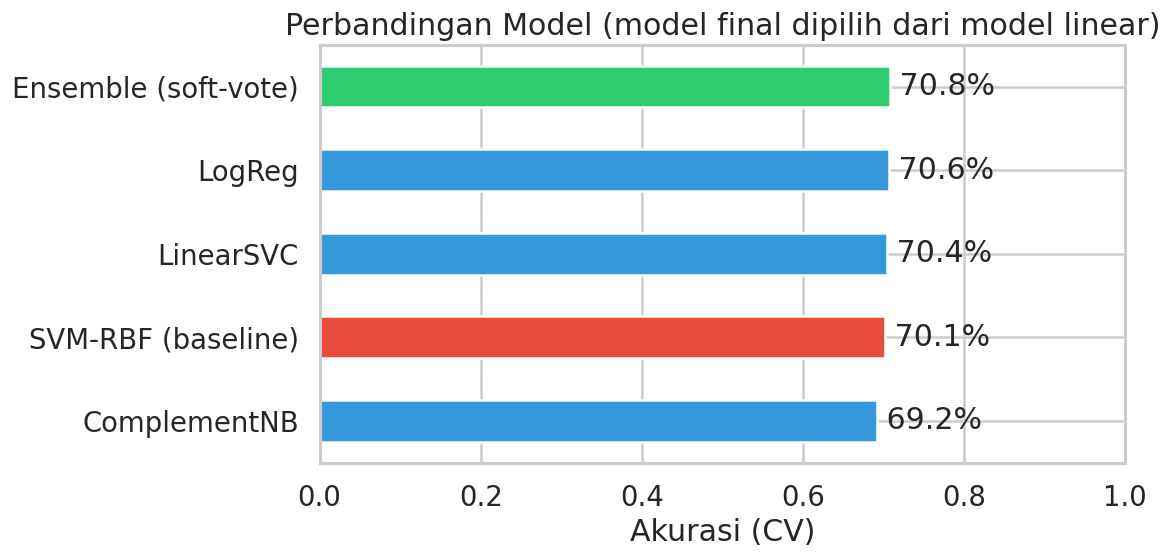


Model final terpilih (linear): Ensemble (soft-vote)


VotingClassifier(estimators=[('logreg',
                              LogisticRegression(C=1, class_weight='balanced',
                                                 max_iter=3000,
                                                 random_state=42)),
                             ('linsvc',
                              CalibratedClassifierCV(estimator=LinearSVC(C=0.5,
                                                                         class_weight='balanced',
                                                                         max_iter=5000,
                                                                         random_state=42))),
                             ('cnb', ComplementNB(alpha=0.3))],
                 voting='soft')

In [7]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=RS)
logreg=LogisticRegression(C=1,class_weight='balanced',max_iter=3000,random_state=RS)
linsvc=CalibratedClassifierCV(LinearSVC(C=0.5,class_weight='balanced',random_state=RS,max_iter=5000))  # dikalibrasi agar bisa ikut soft voting
cnb=ComplementNB(alpha=0.3)
ensemble=VotingClassifier(estimators=[('logreg',logreg),('linsvc',linsvc),('cnb',cnb)],voting='soft')

candidates={'LogReg':logreg,'LinearSVC':linsvc,'ComplementNB':cnb,'Ensemble (soft-vote)':ensemble}
if SHOW_RBF_BASELINE:
    candidates['SVM-RBF (baseline)']=SVC(kernel='rbf',C=10,gamma='scale',class_weight='balanced',random_state=RS)
scores={n:cross_val_score(m,Xtr,y_train,cv=cv,scoring='accuracy').mean() for n,m in candidates.items()}
print('\n=== Perbandingan Model (Akurasi CV) ===')
[print(f'  {n:32s}: {s*100:.2f}%') for n,s in sorted(scores.items(),key=lambda x:-x[1])]

plt.figure(figsize=(10,5)); sm=pd.Series(scores).sort_values()
colors=['#E74C3C' if 'RBF' in n else '#2ECC71' if 'Ensemble' in n else '#3498DB' for n in sm.index]
ax=sm.plot(kind='barh',color=colors); plt.xlabel('Akurasi (CV)'); plt.title('Perbandingan Model (model final dipilih dari model linear)')
for i,v in enumerate(sm): ax.text(v,i,f' {v*100:.1f}%',va='center')
plt.xlim(0,1); savefig('04_perbandingan_model')

# pilih model final terbaik di antara model linear (RBF dikecualikan)
linear_only={n:s for n,s in scores.items() if 'RBF' not in n}
best_name=max(linear_only,key=linear_only.get); clf=candidates[best_name]
print('\nModel final terpilih (linear):',best_name)
clf.fit(Xtr,y_train)

## 5) EVALUASI TEST


Akurasi Test: 69.95%

               precision    recall  f1-score   support

    negative     0.6772    0.6465    0.6615       198
     neutral     0.6550    0.6859    0.6701       191
    positive     0.7650    0.7650    0.7650       200

    accuracy                         0.6995       589
   macro avg     0.6991    0.6991    0.6989       589
weighted avg     0.6998    0.6995    0.6994       589



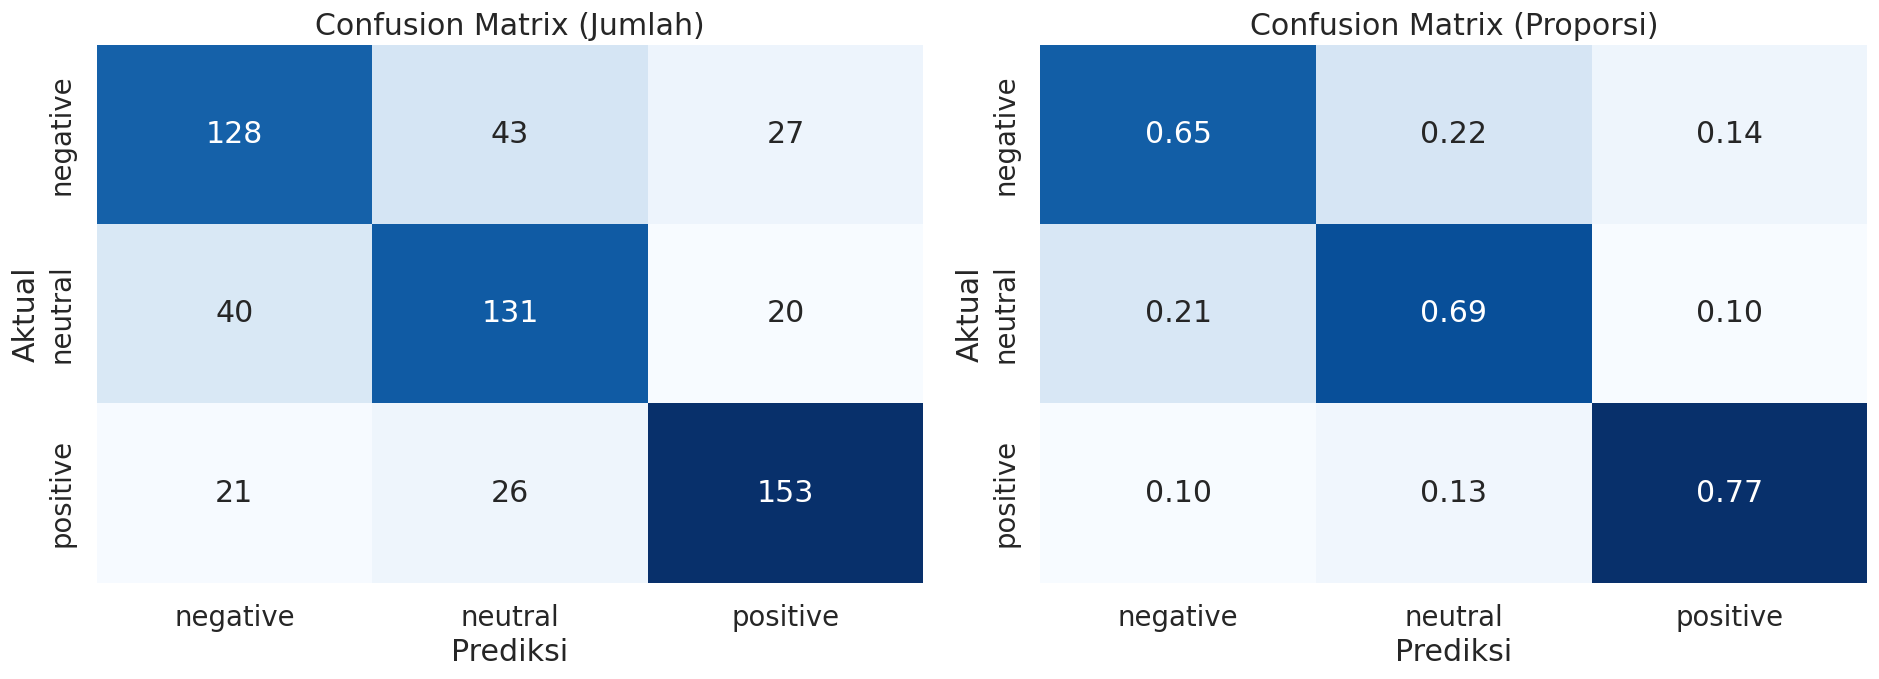

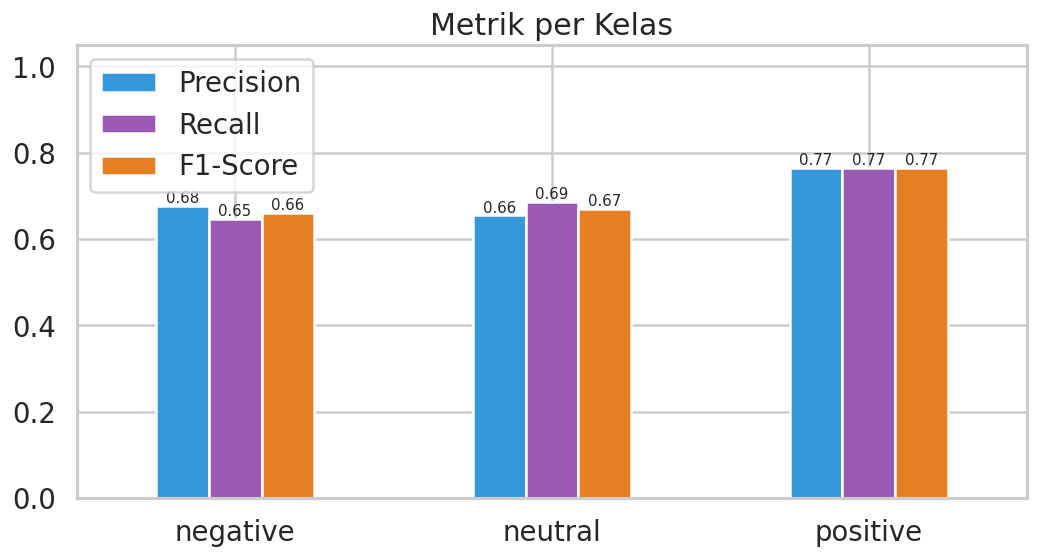

In [8]:
y_pred=clf.predict(Xte)
print(f'\nAkurasi Test: {accuracy_score(y_test,y_pred)*100:.2f}%')
print('\n',classification_report(y_test,y_pred,digits=4))
fig,axes=plt.subplots(1,2,figsize=(16,6))
for ax,norm,title,fmt in [(axes[0],None,'Confusion Matrix (Jumlah)','d'),(axes[1],'true','Confusion Matrix (Proporsi)','.2f')]:
    cm=confusion_matrix(y_test,y_pred,labels=ORDER,normalize=norm)
    sns.heatmap(cm,annot=True,fmt=fmt,cmap='Blues',xticklabels=ORDER,yticklabels=ORDER,ax=ax,cbar=False)
    ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual'); ax.set_title(title)
savefig('05_confusion_matrix')
prec,rec,f1,_=precision_recall_fscore_support(y_test,y_pred,labels=ORDER)
met=pd.DataFrame({'Precision':prec,'Recall':rec,'F1-Score':f1},index=ORDER)
ax=met.plot(kind='bar',figsize=(9,5),color=['#3498DB','#9B59B6','#E67E22']); plt.ylim(0,1.05); plt.xticks(rotation=0); plt.title('Metrik per Kelas')
for c in ax.containers: ax.bar_label(c,fmt='%.2f',fontsize=9)
savefig('06_metrik_per_kelas')

## 6) CROSS-VALIDATION final (angka utama paper)

In [9]:
Xall=feats.transform(X)
cv_acc=cross_val_score(clf,Xall,y,cv=cv,scoring='accuracy'); cv_f1=cross_val_score(clf,Xall,y,cv=cv,scoring='f1_macro')
print(f'\nAkurasi CV 5-Fold : {cv_acc.mean()*100:.2f}% +/- {cv_acc.std()*100:.2f}%')
print(f'F1-macro CV 5-Fold : {cv_f1.mean()*100:.2f}% +/- {cv_f1.std()*100:.2f}%')
import joblib; joblib.dump({'model':clf,'features':feats},'model_svm_v31.joblib')
print('\nSelesai! Grafik di ./figures, model di model_svm_v31.joblib')


Akurasi CV 5-Fold : 71.83% +/- 0.63%
F1-macro CV 5-Fold : 71.75% +/- 0.65%

Selesai! Grafik di ./figures, model di model_svm_v31.joblib


 3-Fold -> Acc 71.39% +/- 0.91% | F1 71.33%
 5-Fold -> Acc 71.83% +/- 0.63% | F1 71.75%
10-Fold -> Acc 72.34% +/- 1.39% | F1 72.25%

=== Ringkasan Variasi K-Fold ===
 k (folds)  Mean Acc (%)  Std (%)  Min (%)  Max (%)  Mean F1 (%)
         3         71.39     0.91    70.74    72.68        71.33
         5         71.83     0.63    71.14    72.79        71.75
        10         72.34     1.39    70.17    74.58        72.25


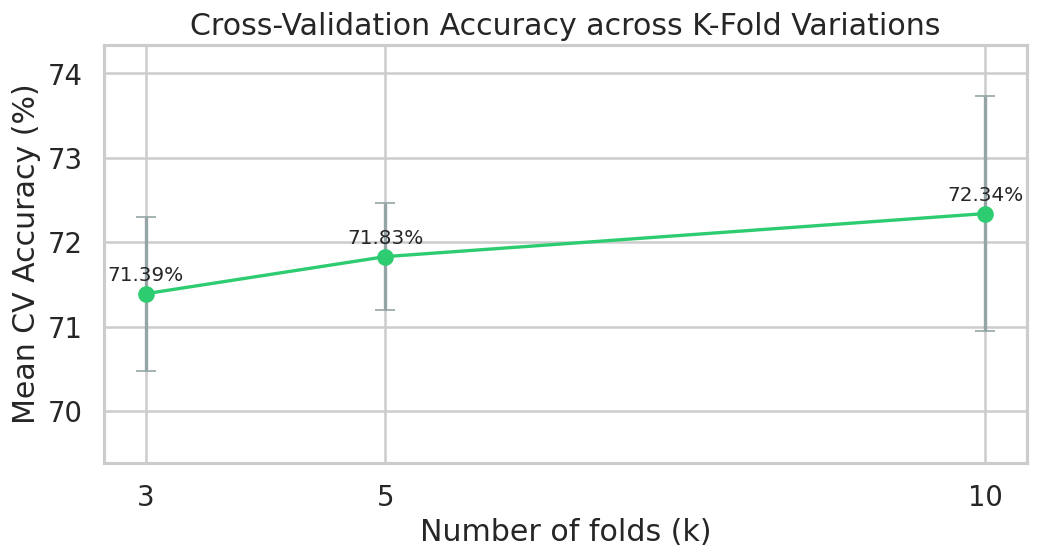

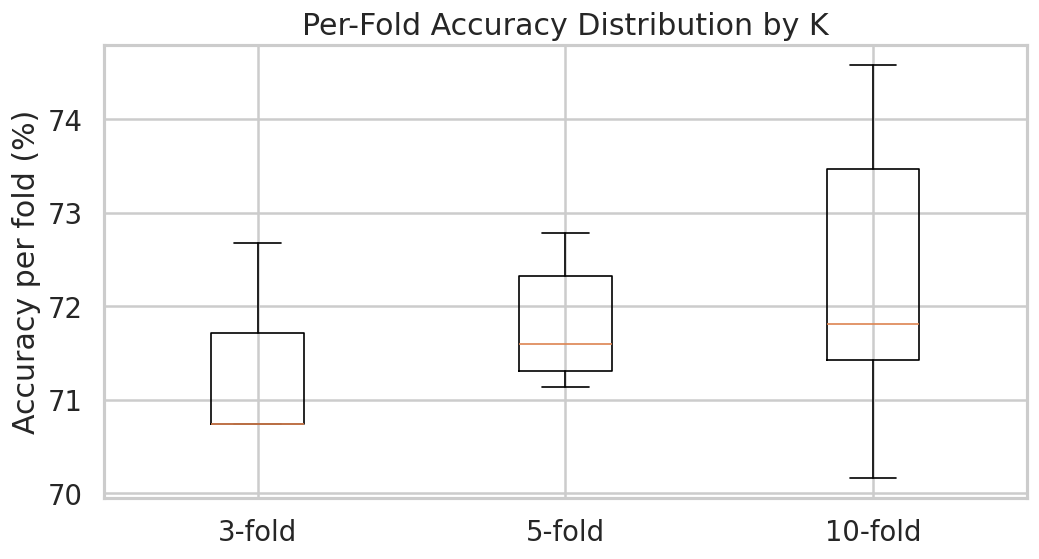


Akurasi per fold:
  3-fold: [np.float64(70.74), np.float64(72.68), np.float64(70.74)]
  5-fold: [np.float64(72.33), np.float64(71.31), np.float64(71.14), np.float64(72.79), np.float64(71.6)]
  10-fold: [np.float64(74.58), np.float64(71.86), np.float64(70.17), np.float64(73.47), np.float64(71.43), np.float64(71.09), np.float64(74.15), np.float64(71.77), np.float64(71.43), np.float64(73.47)]


In [10]:
# Variasi K-Fold (3, 5, 10)
# Jalankan setelah Cell 8 (butuh: clf, Xall, y)
K_VALUES = [3, 5, 10]
kfold_rows, perfold = [], {}

for k in K_VALUES:
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=RS)
    acc = cross_val_score(clf, Xall, y, cv=skf, scoring='accuracy')
    f1  = cross_val_score(clf, Xall, y, cv=skf, scoring='f1_macro')
    perfold[k] = acc
    kfold_rows.append({
        'k (folds)': k,
        'Mean Acc (%)': round(acc.mean()*100, 2),
        'Std (%)':      round(acc.std()*100, 2),
        'Min (%)':      round(acc.min()*100, 2),
        'Max (%)':      round(acc.max()*100, 2),
        'Mean F1 (%)':  round(f1.mean()*100, 2),
    })
    print(f'{k:>2}-Fold -> Acc {acc.mean()*100:.2f}% +/- {acc.std()*100:.2f}% | F1 {f1.mean()*100:.2f}%')

kfold_df = pd.DataFrame(kfold_rows)
print('\n=== Ringkasan Variasi K-Fold ===')
print(kfold_df.to_string(index=False))

# Grafik garis: rata-rata akurasi terhadap jumlah fold (dengan error bar std)
plt.figure(figsize=(9,5))
means = [r['Mean Acc (%)'] for r in kfold_rows]
stds  = [r['Std (%)']      for r in kfold_rows]
plt.errorbar(K_VALUES, means, yerr=stds, marker='o', markersize=9, linewidth=2,
             color='#2ECC71', ecolor='#95A5A6', capsize=6)
for k, m in zip(K_VALUES, means):
    plt.text(k, m+0.15, f'{m:.2f}%', ha='center', fontsize=12)
plt.xticks(K_VALUES); plt.xlabel('Number of folds (k)'); plt.ylabel('Mean CV Accuracy (%)')
plt.title('Cross-Validation Accuracy across K-Fold Variations')
plt.ylim(min(means)-2, max(means)+2)
savefig('07_kfold_variation_line')

# Boxplot distribusi akurasi tiap fold
plt.figure(figsize=(9,5))
plt.boxplot([perfold[k]*100 for k in K_VALUES], labels=[f'{k}-fold' for k in K_VALUES])
plt.ylabel('Accuracy per fold (%)'); plt.title('Per-Fold Accuracy Distribution by K')
savefig('08_kfold_boxplot')

# Nilai akurasi per fold
print('\nAkurasi per fold:')
for k in K_VALUES:
    print(f'  {k}-fold:', [round(a*100,2) for a in perfold[k]])